In [2]:
import shutil
from pathlib import Path

cache_dir = Path("data/cache")
if cache_dir.exists():
    # Supprimer uniquement les fichiers de cache liés à mechanical_faults (optionnel)
    # Mais plus simple : tout supprimer
    shutil.rmtree(cache_dir)
    print("Cache supprimé")
cache_dir.mkdir(parents=True, exist_ok=True)
print("Dossier cache recréé")

Cache supprimé
Dossier cache recréé


In [6]:
import sys
sys.path.append('..')

from backend.ml.adapters.dataset_adapter import DatasetAdapter

adapter_mf = DatasetAdapter('../configs/datasets/mechanical_faults.yaml')
signals_mf = adapter_mf.load(
    '../data/raw/mechanical_faults/Mechanical_faults.zip',
    max_files=200,
    use_cache=True
)

print(f"Signaux chargés : {len(signals_mf)}")
if signals_mf:
    print(f"Shape d'un signal : {signals_mf[0].signals.shape}")

  Sous-ZIPs trouvés : 20
  Stats normalisation : 50 segments sains

  Distribution :
    desalignement        : 1000 fichiers .npy
    desequilibre         : 1000 fichiers .npy
    jeu_mecanique        : 1000 fichiers .npy
    sain                 : 1000 fichiers .npy
  Total : 4000 signaux chargés
  Sauvegarde cache → 845de795abc7.pkl
Signaux chargés : 4000
Shape d'un signal : (9, 4096, 4)


In [8]:
import sys
sys.path.append('..')   # ou sys.path.append('../')

from backend.ml.features.feature_extractor import extract_features_mechanical_faults
from collections import Counter

print("Extraction features spécialisées (128 features)...")
X_mf, y_mf, meta_mf = extract_features_mechanical_faults(
    signals_mf, verbose=True
)
print(f"\nShape X_mf : {X_mf.shape}")
print(f"Distribution : {Counter(y_mf)}")

Extraction features spécialisées (128 features)...
  Signal 0/4000 — Test 06_Normal Condition
  Signal 100/4000 — Test 06_Normal Condition
  Signal 200/4000 — Test 10_Misalignment
  Signal 300/4000 — Test 10_Misalignment
  Signal 400/4000 — Test 02_Misalignment
  Signal 500/4000 — Test 02_Misalignment
  Signal 600/4000 — Test 04_Unbalance
  Signal 700/4000 — Test 04_Unbalance
  Signal 800/4000 — Test 09_Normal Condition
  Signal 900/4000 — Test 09_Normal Condition
  Signal 1000/4000 — Test 01_Normal Condition
  Signal 1100/4000 — Test 01_Normal Condition
  Signal 1200/4000 — Test 08_Looseness
  Signal 1300/4000 — Test 08_Looseness
  Signal 1400/4000 — Test 13_Misalignment
  Signal 1500/4000 — Test 13_Misalignment
  Signal 1600/4000 — Test 12_Looseness
  Signal 1700/4000 — Test 12_Looseness
  Signal 1800/4000 — Test 15_Unbalance
  Signal 1900/4000 — Test 15_Unbalance
  Signal 2000/4000 — Test 16_Misalignment
  Signal 2100/4000 — Test 16_Misalignment
  Signal 2200/4000 — Test 11_Misalign

In [9]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_sample_weight
from collections import defaultdict
import pickle

# Split par test (anti-leakage)
file_groups = defaultdict(list)
file_label  = {}
for i, m in enumerate(meta_mf):
    fid = m['unit_id']
    file_groups[fid].append(i)
    file_label[fid] = y_mf[i]

all_fids    = list(file_groups.keys())
all_flabels = [file_label[f] for f in all_fids]

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, te_idx = next(sss.split(all_fids, all_flabels))

train_idx = [i for j in tr_idx for i in file_groups[all_fids[j]]]
test_idx  = [i for j in te_idx for i in file_groups[all_fids[j]]]

X_train = X_mf[train_idx]
X_test  = X_mf[test_idx]
y_train = [y_mf[i] for i in train_idx]
y_test  = [y_mf[i] for i in test_idx]

print(f"Train : {len(X_train):,} | Test : {len(X_test):,}")

# ── Random Forest ──────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf    = accuracy_score(y_test, y_pred_rf)
print(f"\nRandom Forest : {acc_rf*100:.2f}%")

# ── XGBoost avec pondération renforcée pour la classe 'sain' ──────────────
le = LabelEncoder()
le.fit(y_train + y_test)
y_tr_enc = le.transform(y_train)
y_te_enc = le.transform(y_test)

from sklearn.utils.class_weight import compute_sample_weight

# Calcul des poids équilibrés sur les labels bruts (strings)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Construction d'un dictionnaire classe -> poids
weight_dict = dict(zip(np.unique(y_train), sample_weights))

# Doublement du poids pour la classe 'sain' si elle existe
if 'sain' in weight_dict:
    weight_dict['sain'] *= 2.0

# Application du poids à chaque échantillon d'entraînement
weights = np.array([weight_dict[lab] for lab in y_train])

xgb = XGBClassifier(
    n_estimators=300, max_depth=6,
    learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, eval_metric='mlogloss',
    random_state=42, n_jobs=-1
)
xgb.fit(X_train, y_tr_enc, sample_weight=weights)
y_pred_xgb = le.inverse_transform(xgb.predict(X_test))
acc_xgb    = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost : {acc_xgb*100:.2f}%")
# Rapport du meilleur modèle
best_pred = y_pred_xgb if acc_xgb > acc_rf else y_pred_rf
best_name = "XGBoost" if acc_xgb > acc_rf else "Random Forest"
print(f"\n=== Meilleur modèle : {best_name} ===")
print(classification_report(y_test, best_pred))


Train : 16,000 | Test : 4,000

Random Forest : 74.50%
XGBoost : 76.53%

=== Meilleur modèle : XGBoost ===
               precision    recall  f1-score   support

desalignement       0.52      1.00      0.68      1000
 desequilibre       1.00      1.00      1.00      1000
jeu_mecanique       1.00      1.00      1.00      1000
         sain       1.00      0.06      0.11      1000

     accuracy                           0.77      4000
    macro avg       0.88      0.77      0.70      4000
 weighted avg       0.88      0.77      0.70      4000



In [9]:
from scipy.fft import rfft, rfftfreq
import numpy as np

MF_SHAFT_FREQ = 1238 / 60  # 20.63 Hz

def add_sain_vs_desalign_features(X, signals_mf, meta_mf):
    """
    Ajoute 3 features ultra-ciblées pour distinguer sain vs désalignement :
    - Ratio E(2x) / E(1x) : élevé en désalignement, bas en sain
    - Ratio E(3x) / E(1x) : idem
    - Ratio E(2x) / E_totale : proportion de l'énergie à 2x
    """
    extra_features = []

    for i, m in enumerate(meta_mf):
        # Retrouver le signal correspondant
        sig_idx = next(
            j for j, sig in enumerate(signals_mf)
            if sig.unit_id == m['unit_id']
        )
        sig    = signals_mf[sig_idx]
        w_idx  = m['window_idx']
        window = sig.signals[w_idx]   # (4096, 4)

        feats = []
        for ch in range(4):
            x        = window[:, ch].astype(np.float64)
            N        = len(x)
            spectrum = np.abs(rfft(x)) / N
            freqs    = rfftfreq(N, d=1.0/12800)

            def band_energy(f_center, pct=0.10):
                mask = ((freqs >= f_center*(1-pct)) &
                        (freqs <= f_center*(1+pct)))
                return float(np.sum(spectrum[mask]**2)) + 1e-12

            e1x = band_energy(MF_SHAFT_FREQ * 1)
            e2x = band_energy(MF_SHAFT_FREQ * 2)
            e3x = band_energy(MF_SHAFT_FREQ * 3)
            e_total = float(np.sum(spectrum**2)) + 1e-12

            feats += [
                e2x / e1x,        # ratio 2x/1x
                e3x / e1x,        # ratio 3x/1x
                e2x / e_total,    # proportion énergie à 2x
            ]

        extra_features.append(feats)

    extra = np.array(extra_features, dtype=np.float32)
    print(f"Features supplémentaires : {extra.shape[1]} par échantillon")
    return np.concatenate([X, extra], axis=1)

print("Ajout features différentielles sain/désalignement...")
X_mf_enhanced = add_sain_vs_desalign_features(X_mf, signals_mf, meta_mf)
print(f"Shape X_mf_enhanced : {X_mf_enhanced.shape}")

Ajout features différentielles sain/désalignement...
Features supplémentaires : 12 par échantillon
Shape X_mf_enhanced : (36000, 144)


In [10]:
import pandas as pd
import numpy as np

df_feat = pd.DataFrame(X_mf_enhanced)
df_feat['label'] = y_mf

print("Moyennes par classe (features 0-9) :")
print(df_feat.groupby('label').mean().iloc[:, :10].round(4))

n_nan = np.isnan(X_mf_enhanced).sum()
n_inf = np.isinf(X_mf_enhanced).sum()
print(f"\nNaN  : {n_nan}")
print(f"Inf  : {n_inf}")

if n_nan > 0 or n_inf > 0:
    X_mf_enhanced = np.nan_to_num(X_mf_enhanced, nan=0.0, posinf=0.0, neginf=0.0)
    print("→ Nettoyage appliqué")
else:
    print("✅ Features propres")

Moyennes par classe (features 0-9) :
                    0          1       2        3       4       5       6  \
label                                                                       
desalignement  0.9981   1.779300  0.0398   9.7086  5.3461  0.9981  0.0003   
desequilibre   0.9976   4.626900  0.1018  11.1206  6.3792  0.9975  0.0376   
jeu_mecanique  0.9996   2.680100 -0.0904  10.4428  5.8995  0.9995  0.0173   
sain           0.9977  17.788601  0.0196  14.2900  8.4023  0.9977  0.0002   

                    7       8       9  
label                                  
desalignement  0.0197  0.0016  0.0010  
desequilibre   0.0031  0.0089  0.0007  
jeu_mecanique  0.0225  0.0175  0.0015  
sain           0.0031  0.0008  0.0008  

NaN  : 0
Inf  : 0
✅ Features propres


In [15]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_sample_weight
from collections import defaultdict
import pickle

# Split par test (anti-leakage)
file_groups = defaultdict(list)
file_label  = {}
for i, m in enumerate(meta_mf):
    fid = m['unit_id']
    file_groups[fid].append(i)
    file_label[fid] = y_mf[i]

all_fids    = list(file_groups.keys())
all_flabels = [file_label[f] for f in all_fids]

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, te_idx = next(sss.split(all_fids, all_flabels))

train_idx = [i for j in tr_idx for i in file_groups[all_fids[j]]]
test_idx  = [i for j in te_idx for i in file_groups[all_fids[j]]]

X_train = X_mf_enhanced[train_idx]
X_test  = X_mf_enhanced[test_idx]

y_train = [y_mf[i] for i in train_idx]
y_test  = [y_mf[i] for i in test_idx]

print(f"Train : {len(X_train):,} | Test : {len(X_test):,}")

# ── Random Forest ──────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=100, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf    = accuracy_score(y_test, y_pred_rf)
print(f"\nRandom Forest : {acc_rf*100:.2f}%")

# ── XGBoost avec pondération renforcée pour la classe 'sain' ──────────────
le = LabelEncoder()
le.fit(y_train + y_test)
y_tr_enc = le.transform(y_train)
y_te_enc = le.transform(y_test)

from sklearn.utils.class_weight import compute_sample_weight

# Calcul des poids équilibrés sur les labels bruts (strings)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Construction d'un dictionnaire classe -> poids
weight_dict = dict(zip(np.unique(y_train), sample_weights))

# Doublement du poids pour la classe 'sain' si elle existe
if 'sain' in weight_dict:
    weight_dict['sain'] *= 4.0

# Application du poids à chaque échantillon d'entraînement
weights = np.array([weight_dict[lab] for lab in y_train])

xgb = XGBClassifier(
    n_estimators=300, max_depth=6,
    learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, eval_metric='mlogloss',
    random_state=42, n_jobs=-1
)
xgb.fit(X_train, y_tr_enc, sample_weight=weights)
y_pred_xgb = le.inverse_transform(xgb.predict(X_test))
acc_xgb    = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost : {acc_xgb*100:.2f}%")
# Rapport du meilleur modèle
best_pred = y_pred_xgb if acc_xgb > acc_rf else y_pred_rf
best_name = "XGBoost" if acc_xgb > acc_rf else "Random Forest"
print(f"\n=== Meilleur modèle : {best_name} ===")
print(classification_report(y_test, best_pred))


Train : 28,800 | Test : 7,200

Random Forest : 80.39%
XGBoost : 61.11%

=== Meilleur modèle : Random Forest ===
               precision    recall  f1-score   support

desalignement       0.56      1.00      0.72      1800
 desequilibre       1.00      1.00      1.00      1800
jeu_mecanique       1.00      1.00      1.00      1800
         sain       1.00      0.22      0.36      1800

     accuracy                           0.80      7200
    macro avg       0.89      0.80      0.77      7200
 weighted avg       0.89      0.80      0.77      7200



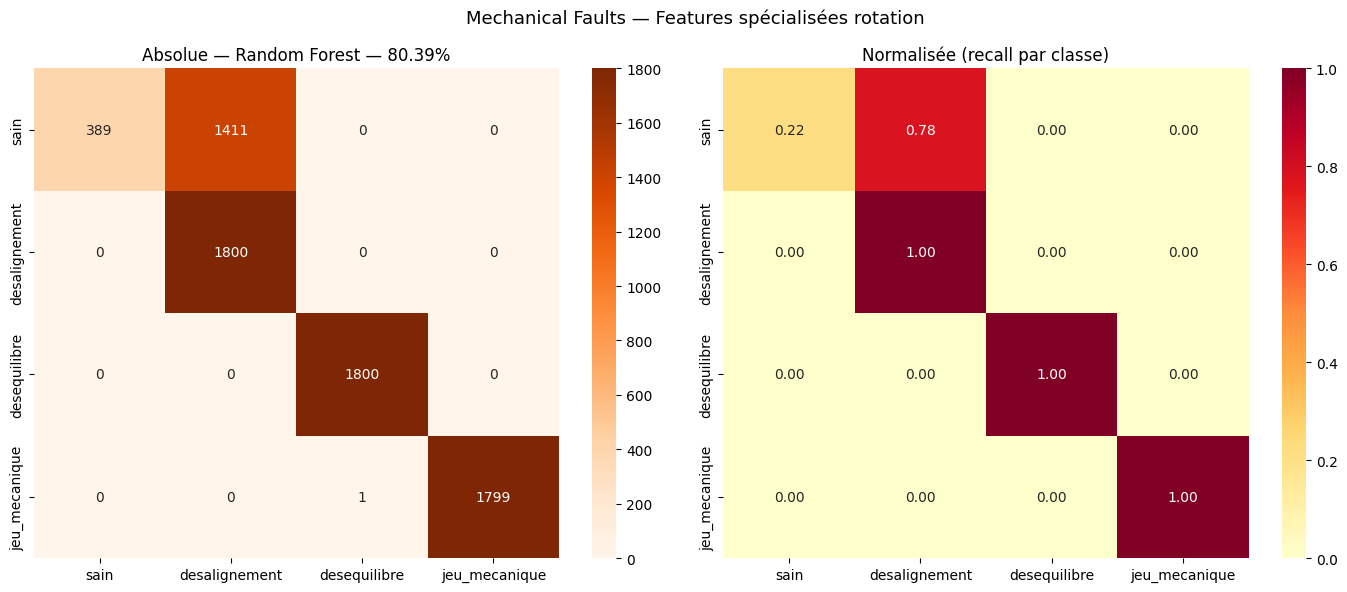


 Sauvegardé

=== BILAN MECHANICAL FAULTS ===
  Random Forest : 80.39%
  XGBoost       : 61.11%
  Features      : 132 (spécialisées rotation)


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

labels_ord = ['sain', 'desalignement', 'desequilibre', 'jeu_mecanique']
best_acc   = max(acc_rf, acc_xgb)
cm = confusion_matrix(y_test, best_pred, labels=labels_ord)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=labels_ord, yticklabels=labels_ord,
            ax=axes[0])
axes[0].set_title(f'Absolue — {best_name} — {best_acc*100:.2f}%')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=labels_ord, yticklabels=labels_ord,
            ax=axes[1])
axes[1].set_title('Normalisée (recall par classe)')

plt.suptitle('Mechanical Faults — Features spécialisées rotation', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix_mf_v2.png', dpi=150)
plt.show()

# Sauvegarde
np.save('../data/processed/X_mf.npy', X_mf)
with open('../data/processed/y_mf.pkl', 'wb') as f:
    pickle.dump(y_mf, f)
with open('../data/processed/meta_mf.pkl', 'wb') as f:
    pickle.dump(meta_mf, f)

print(f"\n Sauvegardé")
print(f"\n=== BILAN MECHANICAL FAULTS ===")
print(f"  Random Forest : {acc_rf*100:.2f}%")
print(f"  XGBoost       : {acc_xgb*100:.2f}%")
print(f"  Features      : {X_mf.shape[1]} (spécialisées rotation)")